# cc-1.1 — Act-PRM x tau2 **retail**: Stage-2 SFT results

Training / eval curves + comparison for the Stage-2 SFT sweep, reconstructed
from the per-run `metrics.jsonl` (`tinker_cookbook.utils.ml_log`, one row per
step; the eval branch flushes an extra row per eval — we dedupe on
`progress/batch`, keeping the last merged row).

Stage-2 matrix (see `notes/cc-2.0`, `cc-2.1`): **variant** (`actions_only`,
`expert_thoughts`, `thoughts_policy`, `thoughts_base`) x **regime**
(`hide`-obs / `full`-context) x **best/last** corpus (thought variants relabel
from the Stage-1 `step_best` vs `step_last` checkpoint; the `_last` runs use the
fully-trained EM checkpoint).

Encoding used throughout: **color = variant**, **linestyle = regime**
(solid=hide, dashed=full), **marker = corpus** (o=best, s=last).

This notebook auto-discovers every `retail_s2_*` run and **degrades gracefully**
while the sweep is still in progress (missing runs are skipped, empty data is
guarded — it never raises).

In [1]:
# === CONFIG: where the runs live ============================================
from pathlib import Path  # (also imported in the SETUP cell below; safe)


def _repo_root(start=None):
    # Walk up to the repo root (dir with pyproject.toml + notebooks/) so paths
    # resolve whether launched from the repo root or from notebooks/.
    p = (Path(start) if start else Path.cwd()).resolve()
    for c in (p, *p.parents):
        if (c / "pyproject.toml").exists() and (c / "notebooks").exists():
            return c
    return Path.cwd()


REPO = _repo_root()
# Root under which each run writes <run_tag>-.../metrics.jsonl .
LOGROOT = REPO / "logs" / "act_prm_tau2_retail" / "hf_qwen3_4b_instruct"

# Glob for Stage-2 SFT run dirs. Tag: retail_s2_<variant>_heldout[_fullctx].
SFT_GLOB = "retail_s2_*"

DOMAIN = "retail"  # domain prefix -> never collides with the airline box on merge
print("LOGROOT:", LOGROOT, "| exists:", LOGROOT.exists())

LOGROOT: /home/mzio/projects/act-prm-blog/logs/act_prm_tau2_retail/hf_qwen3_4b_instruct | exists: True


In [2]:
# === SETUP: headless backend + imports =======================================
import matplotlib
# Non-interactive rendering: the inline backend (Agg-based) is headless AND
# embeds figures as PNGs under nbconvert/jupyter; fall back to bare Agg if we
# are not running inside an IPython kernel.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    matplotlib.use("Agg")

import json, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110})

# Brand-neutral, colorblind-safe categorical palette.
PALETTE = ["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756", "#72B7B2"]


def load_metrics(mfile) -> pd.DataFrame:
    """Load a run's metrics.jsonl -> DataFrame, deduped on progress/batch
    (keep last: the eval flush writes a partial row before the merged one).
    Returns an empty frame (no exception) if the file is missing/empty."""
    mfile = Path(mfile)
    if not mfile.is_file():
        return pd.DataFrame()
    rows = []
    for line in mfile.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            pass
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    if "progress/batch" in df:
        df = (df.drop_duplicates("progress/batch", keep="last")
                .sort_values("progress/batch").reset_index(drop=True))
    return df


def _xy(df, col, xcol="progress/batch"):
    """(x, y) for a metric column, dropping rows where it is NaN/absent."""
    if df is None or df.empty or col not in df:
        return None, None
    keep = [c for c in (xcol, col) if c in df]
    sub = df[keep].dropna()
    if sub.empty:
        return None, None
    x = sub[xcol] if xcol in sub else np.arange(len(sub))
    return x, sub[col]


In [3]:
# === DISCOVER Stage-2 runs + parse (variant, regime, corpus) from the tag =====
VARIANTS = ["actions_only", "expert_thoughts", "thoughts_policy", "thoughts_base"]
VARIANT_COLOR = {v: PALETTE[i] for i, v in enumerate(VARIANTS)}
REGIME_LS = {"hide": "-", "full": "--"}
CORPUS_MARKER = {"best": "o", "last": "s"}


def parse_tag(tag: str):
    """retail_s2_<variant>[_last]_heldout[_fullctx] -> (variant, regime, corpus)."""
    t = tag
    regime = "full" if t.endswith("_fullctx") else "hide"
    t = t[: -len("_fullctx")] if t.endswith("_fullctx") else t
    t = t[: -len("_heldout")] if t.endswith("_heldout") else t
    t = re.sub(rf"^{DOMAIN}_s2_", "", t)
    corpus = "last" if t.endswith("_last") else "best"
    variant = t[: -len("_last")] if t.endswith("_last") else t
    return variant, regime, corpus


def discover_runs(logroot: Path, glob: str) -> dict:
    """label -> {df, variant, regime, corpus, dir}. Empty if nothing found."""
    runs = {}
    if not logroot.exists():
        warnings.warn(f"log root missing: {logroot}")
        return runs
    for d in sorted(logroot.glob(glob)):
        if not d.is_dir():
            continue
        tag = d.name.split("-act-prm")[0]
        variant, regime, corpus = parse_tag(tag)
        df = load_metrics(d / "metrics.jsonl")
        label = f"{variant} [{regime},{corpus}]"
        runs[label] = {"df": df, "variant": variant, "regime": regime,
                       "corpus": corpus, "dir": d, "n": 0 if df.empty else len(df)}
    return runs


def style(meta):
    return dict(color=VARIANT_COLOR.get(meta["variant"], "#888888"),
                linestyle=REGIME_LS.get(meta["regime"], ":"),
                marker=CORPUS_MARKER.get(meta["corpus"], "x"))


RUNS = discover_runs(LOGROOT, SFT_GLOB)
if not RUNS:
    print("No retail_s2_* runs found yet (sweep in progress) — plots will be empty.")
else:
    for lbl, m in RUNS.items():
        print(f"{lbl:36s} rows={m['n']:3d}  ({m['dir'].name[:60]}...)")

actions_only [hide,best]             rows= 60  (retail_s2_actions_only_heldout-act-prm-ia=0-rr=0-ec=act_prm_...)


In [4]:
# === PLOT helper: overlay one metric across discovered runs ==================
def plot_metric(runs: dict, col: str, title: str, ylabel: str, ax=None):
    ax = ax or plt.gca()
    plotted = 0
    for label, meta in runs.items():
        x, y = _xy(meta["df"], col)
        if x is None:
            continue
        ax.plot(x, y, ms=4, lw=1.6, label=label, **style(meta))
        plotted += 1
    ax.set(title=title, xlabel="step (progress/batch)", ylabel=ylabel)
    if plotted:
        ax.legend(fontsize=7)
    else:
        ax.text(0.5, 0.5, "no data yet", ha="center", va="center",
                transform=ax.transAxes, color="gray")
    return ax

print("plot_metric ready")

plot_metric ready


## (a) Train curves — `train/loss` and `train/ppl` vs step

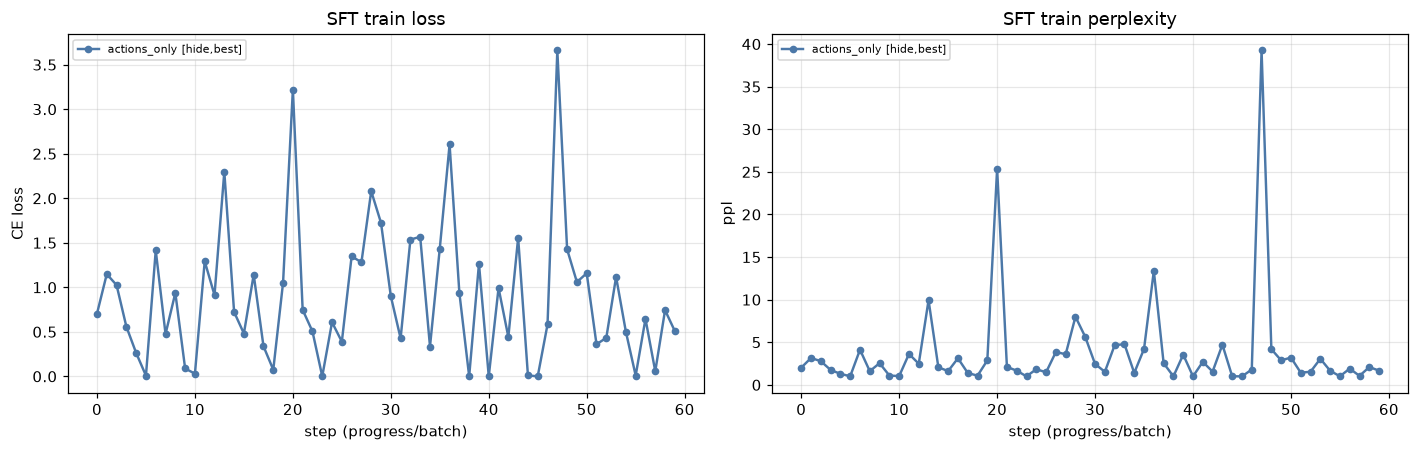

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
plot_metric(RUNS, "train/loss", "SFT train loss", "CE loss", axes[0])
plot_metric(RUNS, "train/ppl", "SFT train perplexity", "ppl", axes[1])
plt.tight_layout(); plt.show()

## (b) Held-out eval curves — `eval/eval_action_ppl` and `eval/eval_action_accuracy`

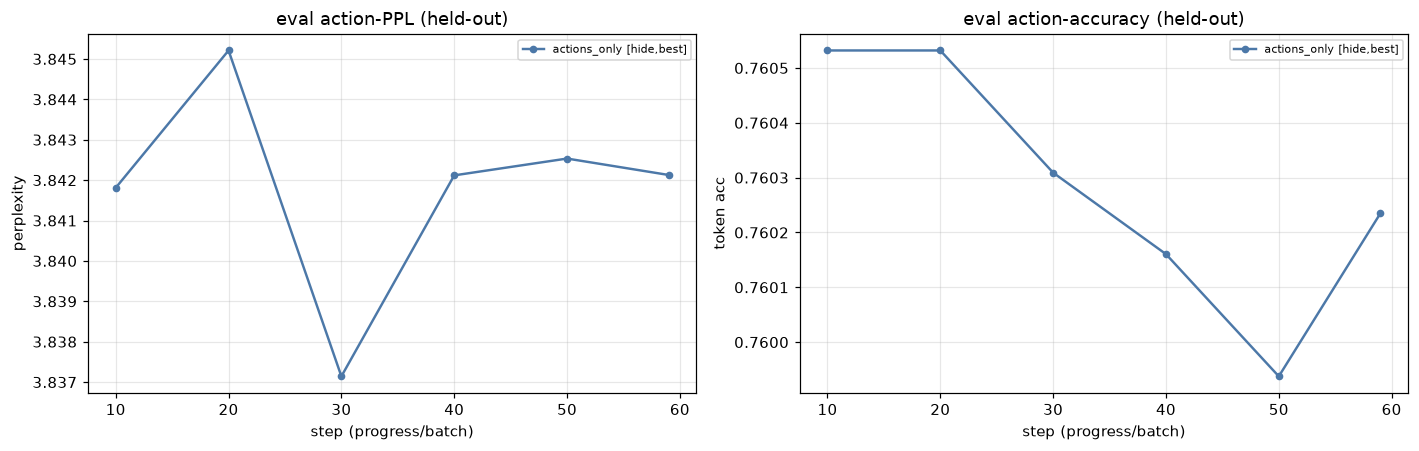

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
plot_metric(RUNS, "eval/eval_action_ppl", "eval action-PPL (held-out)", "perplexity", axes[0])
plot_metric(RUNS, "eval/eval_action_accuracy", "eval action-accuracy (held-out)", "token acc", axes[1])
plt.tight_layout(); plt.show()

## (c) Summary — best held-out action-PPL per (variant x regime x best/last)

Best = early-stop point (lowest eval action-PPL over the run). Uses
`eval/eval_action_ppl_best` when logged (written under `best_metric:
eval_action_ppl`), else the min of the eval curve. Bar color = variant,
hatch = regime (`//` = full-context), and the corpus (best/last) is annotated.

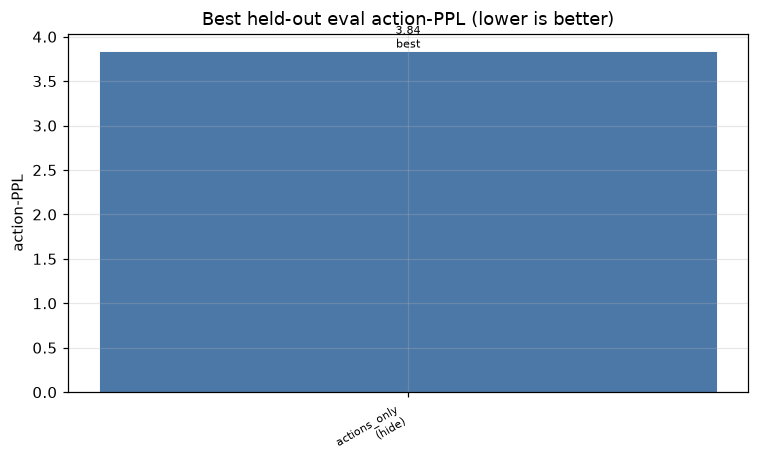

,label,variant,regime,corpus,best_eval_action_ppl
0,"actions_only [hide,best]",actions_only,hide,best,3.837143


In [7]:
def best_ppl(df):
    if df is None or df.empty:
        return np.nan
    if "eval/eval_action_ppl_best" in df:
        v = df["eval/eval_action_ppl_best"].dropna()
        if len(v):
            return float(v.iloc[-1])
    if "eval/eval_action_ppl" in df:
        v = df["eval/eval_action_ppl"].dropna()
        if len(v):
            return float(v.min())
    return np.nan


rows = []
for label, m in RUNS.items():
    bp = best_ppl(m["df"])
    if not np.isnan(bp):
        rows.append({"label": label, "variant": m["variant"], "regime": m["regime"],
                     "corpus": m["corpus"], "best_eval_action_ppl": bp})

summary = pd.DataFrame(rows)
if summary.empty:
    print("No eval PPL points yet — summary bar chart skipped.")
else:
    summary = summary.sort_values(
        ["variant", "regime", "corpus"],
        key=lambda s: s.map({**{v: i for i, v in enumerate(VARIANTS)},
                             "hide": 0, "full": 1, "best": 0, "last": 1}).fillna(9)
    ).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(max(7, 1.1 * len(summary)), 4.4))
    for i, r in summary.iterrows():
        ax.bar(i, r["best_eval_action_ppl"],
               color=VARIANT_COLOR.get(r["variant"], "#888"),
               hatch=("//" if r["regime"] == "full" else None),
               edgecolor="white", linewidth=0.6)
        ax.text(i, r["best_eval_action_ppl"], f"{r['best_eval_action_ppl']:.2f}\n{r['corpus']}",
                ha="center", va="bottom", fontsize=7)
    ax.set_xticks(range(len(summary)))
    ax.set_xticklabels([f"{r.variant}\n({r.regime})" for r in summary.itertuples()],
                       rotation=30, ha="right", fontsize=7)
    ax.set(title="Best held-out eval action-PPL (lower is better)", ylabel="action-PPL")
    plt.tight_layout(); plt.show()
    display(summary)

## Caveat — eval span is **not** apples-to-apples across variants

From `notes/cc-4.0`: `eval/eval_action_ppl` teacher-forces the **whole target
span**, so the thought variants (`expert_thoughts`, `thoughts_policy`,
`thoughts_base`) include the (harder) *thought* tokens, while `actions_only`
scores only the action tokens. A higher PPL for a thought variant therefore
does **not** by itself mean thoughts hurt next-action fit — the spans differ.

A fair comparison needs an **action-subspan PPL** (PPL over only the action
tokens, excluding thoughts); until that metric is logged, read the thought vs
`actions_only` gap with caution. `eval/try_0/action_tokens` (present in the SFT
eval rows) is the action-token count and is the hook for that subspan metric.

Eval **is** run under the same context regime as training
(`eval_env == train_env`), so hide vs full comparisons within a variant are
consistent.